## Constants now loaded from data
The placeholder constants were replaced with values measured from the 2026-02-18 run (see reduction/, loaded from reduction/constants.json). Corrections vs. the original notebook:

| Constant | old (placeholder) | now |
|---|---|---|
| dark current | 21.085 e-/s | ~0.38 e-/s (from darks) |
| read noise (8 MHz) | 14 e- | ~19.5 e- (from bias pairs) |
| gain | 1.56 e-/ADU | ~1.50 e-/ADU (photon transfer) |
| zero point | round numbers | from photometry (APASS cross-match) |
| extinction k | air-quality table | INTERIM typical values (this night could not constrain it; ZP anchored on M67) |
| R_sky | round numbers | measured per filter from the cluster frames |

Run python reduction/run_all.py to regenerate constants.json. The air_quality input is no longer used.

This notebook should be a simple ETC besed on the following equation
$$
\frac{S}{N} = \frac{N_*}{\sqrt{N_* + n_{pix}(N_S + N_D + N_R)}}
$$
Where $N$ is the number of elesctrons detected. To calculate the exposure time $t$ we use the rate $R$ of electrons per second.
$$
N = R \cdot t
$$

Since we want to know the exposure time $t$ we have to rearange the formular yielding a quadratic equation
$$
R_*^2 t^2 - (SNR)^2(R_* + n_{pix}(R_S + R_D))t - (SNR)^2n_{pix}N_R = 0
$$

In [1]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

In [2]:
# --- Derived instrumental constants (reduction/run_all.py) ---
import json, os
with open(os.path.join('reduction', 'constants.json')) as _f:
    CONST = json.load(_f)
gain = CONST['camera']['gain_e_per_adu']
SAT_ADU = CONST['camera']['saturation_adu']
CONST['camera']

{'gain_e_per_adu': 1.5006,
 'read_noise_e': {'8 MHz': 19.476, '1 MHz': 17.864},
 'dark_current_e_per_s_at_-5C': 0.3847,
 'saturation_adu': 65535}

The user only has to input the values in the following cell.

In [3]:
# user inputs
#############

# TARGET
mag = 2.            # brightness of the target
snr = 10            # target snr
# possible addition: pointlike vs. extended targets

# ATMOOSPHERE
airmass = 1.5           # value bigger than 1
air_quality = 3         # value from 1 to 5, 1=excellent, 5=very bad
seeing = 1.8            # seeing in arcseconds, typically between 1.7 and 2.5 for vienna
# moon_fli = 0.5        # moon illumination fraction, requires a sky model
# moon_distance = 45    # moon distance in deg

# CAMERA
binning = 2
read_mode = '8 MHz'     # options: '8 MHz', '1 MHz'
used_filter = 'V'       # options: 'B', 'V', 'R', 'I', maybe later 'Halpha', 'SII', 'OIII'
exp_time = 20          # exposure time in seconds
# set_temp = -5         # not implemented yet

The value of $n_{pix}$ is calcualted based on the expected seeing and the used binning. It is basically just the area of circualar the aperture.

In [4]:
d = 80*u.cm     # diameter of the telescope
f = d*8.3       # focal length
s = np.arctan(9*u.micron/f).to(u.arcsec)/u.pixel
print(f"Pixel scale: {s:.4f}")

Pixel scale: 0.2796 arcsec / pix


In [5]:
def get_npix(fwhm:float, binning:int=2, aperture:float=3.0):
    """calculates the number of pixels

    :param fwhm: seeing fwhm size in arcsec
    :type fwhm: float
    :param binning: binning used in the observation, defaults to 2
    :type binning: int, optional
    :param aperture: aperture size as multiple of fwhm, defaults to 3.0
    :type aperture: float, optional
    """
    s = 0.27957579   # arcsec/px
    r = aperture * fwhm/2 / s / binning
    A = r**2 * np.pi
    n_pix = A
    return n_pix

In [6]:
n_pix = get_npix(seeing, binning)

In [7]:
# read noise per readout mode (electrons) -- derived from bias frames
read_mode_vals = CONST['camera']['read_noise_e']
N_readout = read_mode_vals[read_mode]

The dark current $R_{D}$ depends on the temperature and can be described by an exponential function. Since we usually coool the camera to -5°C I use this value, but might add a temperature dependent model later.

In [8]:
# dark current (e-/s @ -5C) -- derived from dark frames
R_dark = CONST['camera']['dark_current_e_per_s_at_-5C']

The flux from the sky $R_S$ actually depends also on the moon illumination and the moon distance. To include this in the calculation I would need to add a sky model. Might come later, if the rest is working and yields reasonable results.

In [9]:
# sky background rate (e-/s/binned pixel) -- derived from the cluster frames
R_sky_vals = {f: CONST['filters'][f]['sky_rate_e_per_s_per_pix']
              for f in CONST['filters']}
R_sky = R_sky_vals[used_filter]

The flux from the star $R_*$ obviously mainly depends on the brightness and the atmospheric extinction $k$ and the airmass. The zero point is just an ofset to convert from true magnitudes to instrumental magnitudes.

In [10]:
# zero points and extinction coefficients -- derived via Bouguer fit
ZP_vals = {f: CONST['filters'][f]['zeropoint_mag_1es'] for f in CONST['filters']}
k_vals  = {f: CONST['filters'][f]['extinction_k']      for f in CONST['filters']}

def get_R_star(mag, filt, airmass):
    ZP = ZP_vals[filt]
    k = k_vals[filt]
    return 10**(0.4*(ZP - (mag + k*airmass)))

R_star = get_R_star(mag, used_filter, airmass)

Solving the quadratic equation for a given SNR finally yields the exposure time.

In [11]:
# solve it
a = R_star**2
b = -snr**2 * (R_star + n_pix*(R_sky + R_dark))
c = -snr**2*n_pix*N_readout**2

t = (-b + np.sqrt(b**2 - 4*a*c))/(2*a)

print(f"Brightness:\t{mag} mag")
print(f"Filter:\t\t{used_filter}")
print(f"SNR:\t\t{snr}")
print(f"Exposure time:\t{t:.4f} s")

Brightness:	2.0 mag
Filter:		V
SNR:		10
Exposure time:	0.0000 s


In [12]:
snr_calc = R_star*exp_time / np.sqrt(R_star*exp_time + n_pix*(exp_time*(R_sky + R_dark) + N_readout**2))

print(f"Brightness:\t{mag} mag")
print(f"Filter:\t\t{used_filter}")
print(f"Exposure time:\t{exp_time:.2f} s")
print(f"SNR:\t\t{snr_calc:.4f}")

Brightness:	2.0 mag
Filter:		V
Exposure time:	20.00 s
SNR:		42682.3297


(35710.48243706394, 50502.523654059994)

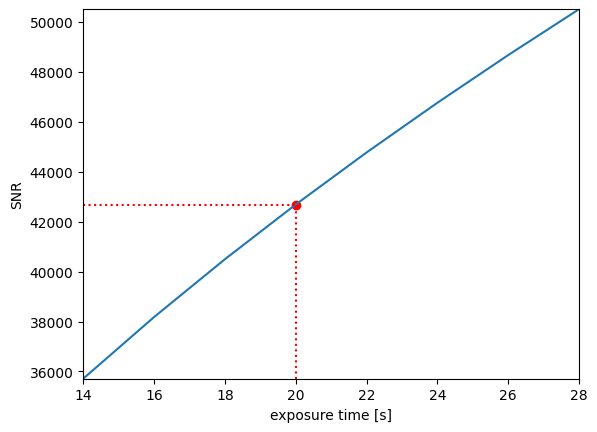

In [13]:
expo_vals = np.arange(max(0, exp_time*0.7), exp_time*1.5, 2)
snr_vals = [R_star*et / np.sqrt(R_star*et + n_pix*(et*(R_sky + R_dark) + N_readout**2)) for et in expo_vals]

plt.plot(expo_vals, snr_vals)
plt.scatter(exp_time, snr_calc, color='r')
plt.vlines(exp_time, snr_vals[0], snr_calc, color='r', linestyles=':')
plt.hlines(snr_calc, expo_vals[0], exp_time, color='r', linestyles=':')
plt.xlabel('exposure time [s]')
plt.ylabel('SNR')
plt.xlim((expo_vals[0], expo_vals[-1]))
plt.ylim((snr_vals[0], snr_vals[-1]))

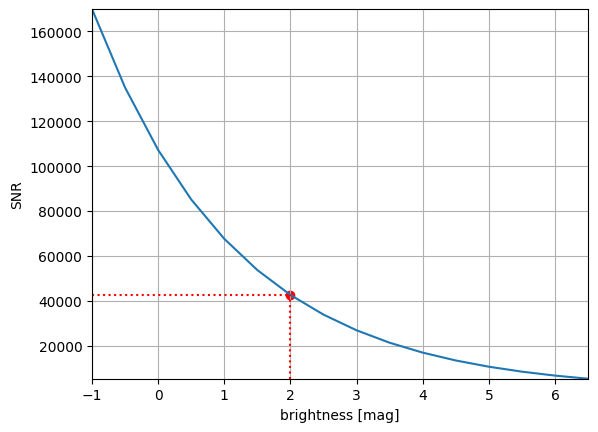

In [14]:
mag_vals = np.arange(mag-3, mag+5, 0.5)
R_star_vals = get_R_star(mag_vals, used_filter, airmass)
snr_vals = [Rs*exp_time / np.sqrt(Rs*exp_time + n_pix*(exp_time*(R_sky + R_dark) + N_readout**2)) for Rs in R_star_vals]

plt.plot(mag_vals, snr_vals)
plt.scatter(mag, snr_calc, color='r')
plt.vlines(mag, snr_vals[-1], snr_calc, color='r', linestyles=':')
plt.hlines(snr_calc, mag_vals[0], mag, color='r', linestyles=':')
plt.xlabel('brightness [mag]')
plt.ylabel('SNR')
# plt.semilogy()
plt.xlim((mag_vals[0], mag_vals[-1]))
plt.ylim((snr_vals[-1], snr_vals[0]))
plt.grid(which='both')

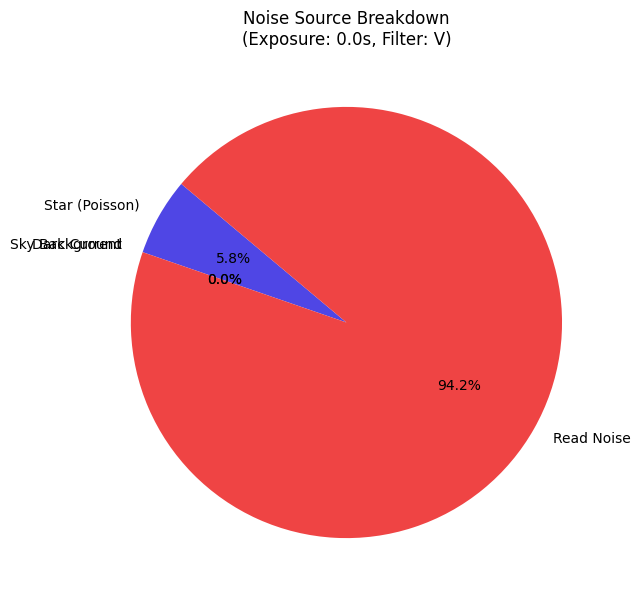

In [15]:
# Calculate individual noise components (variance)
noise_star = R_star * t
noise_sky = n_pix * R_sky * t
noise_dark = n_pix * R_dark * t
noise_read = n_pix * N_readout**2

labels = ['Star (Poisson)', 'Sky Background', 'Dark Current', 'Read Noise']
values = [noise_star, noise_sky, noise_dark, noise_read]

plt.figure(figsize=(7, 7))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=['#4f46e5', '#9aa6bf', '#f59e0b', '#ef4444'])
plt.title(f'Noise Source Breakdown\n(Exposure: {t:.1f}s, Filter: {used_filter})')
plt.show()

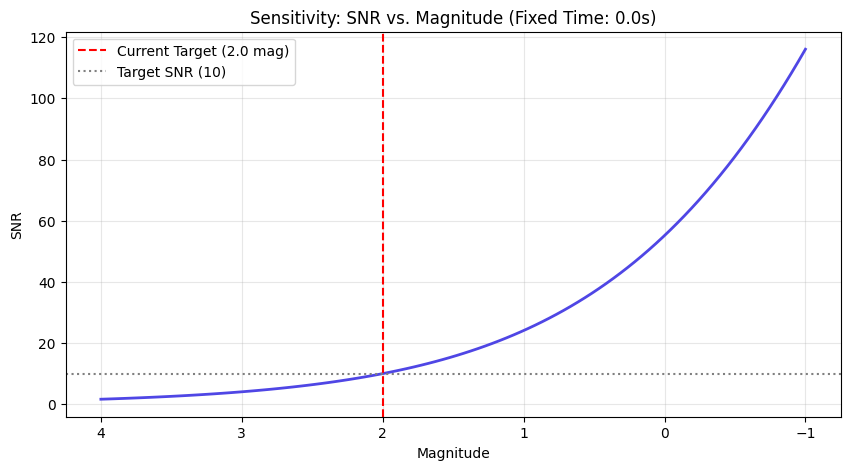

In [16]:
# Generate range of magnitudes
mags = np.linspace(mag - 3, mag + 2, 100)
snrs_mag = []

for m in mags:
    r_s = get_R_star(m, used_filter, airmass)
    # Calculate SNR using the calculated exposure time t
    snr_i = (r_s * t) / np.sqrt(r_s * t + n_pix * (t * (R_sky + R_dark) + N_readout**2))
    snrs_mag.append(snr_i)

plt.figure(figsize=(10, 5))
plt.plot(mags, snrs_mag, color='#4f46e5', lw=2)
plt.axvline(mag, color='red', linestyle='--', label=f'Current Target ({mag} mag)')
plt.axhline(snr, color='gray', linestyle=':', label=f'Target SNR ({snr})')
plt.xlabel('Magnitude')
plt.ylabel('SNR')
plt.title(f'Sensitivity: SNR vs. Magnitude (Fixed Time: {t:.1f}s)')
plt.gca().invert_xaxis() # Brighter stars (lower mag) on the left
plt.grid(alpha=0.3)
plt.legend()
plt.show()

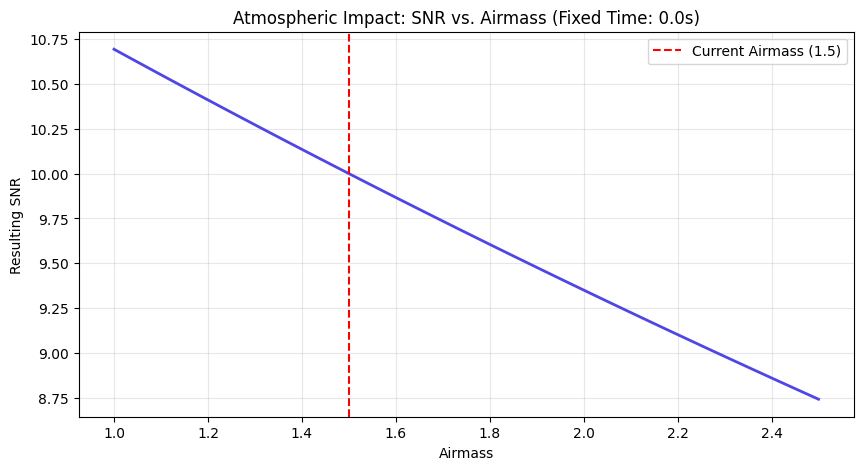

In [17]:
# Generate range of airmasses (1.0 = zenith, 2.5 = low horizon)
airmasses = np.linspace(1.0, 2.5, 50)
snrs_air = []

for am in airmasses:
    r_s = get_R_star(mag, used_filter, am)
    snr_i = (r_s * t) / np.sqrt(r_s * t + n_pix * (t * (R_sky + R_dark) + N_readout**2))
    snrs_air.append(snr_i)

plt.figure(figsize=(10, 5))
plt.plot(airmasses, snrs_air, color='#4f46e5', lw=2)
plt.axvline(airmass, color='red', linestyle='--', label=f'Current Airmass ({airmass})')
plt.xlabel('Airmass')
plt.ylabel('Resulting SNR')
plt.title(f'Atmospheric Impact: SNR vs. Airmass (Fixed Time: {t:.1f}s)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

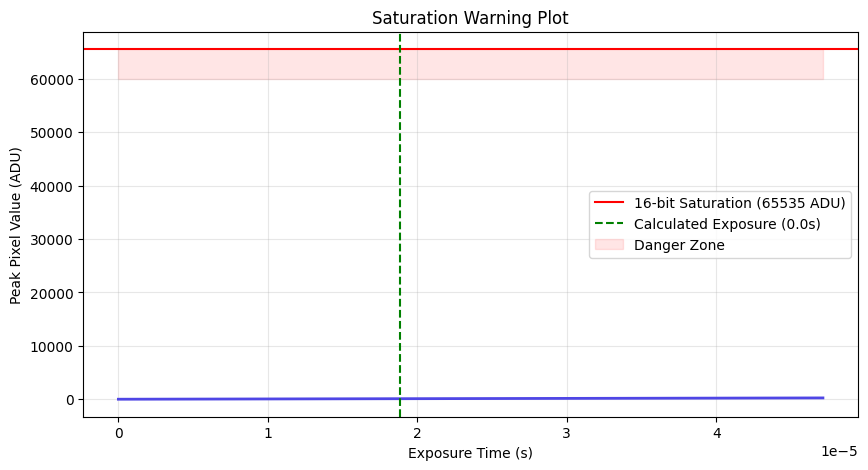

In [18]:
# Camera constants
gain = CONST['camera']['gain_e_per_adu']
pixel_scale = 0.27957579 

# Estimate peak star flux per pixel (Gaussian approximation)
# sigma in binned pixels
sigma_px = (seeing / pixel_scale) / 2.355 / binning
peak_star_rate = R_star / (2 * np.pi * sigma_px**2)

# Generate time range
times = np.linspace(0, t * 2.5, 100)
peaks_adu = []

for ti in times:
    # Total peak = (Peak Star + Sky + Dark) * time
    peak_e = (peak_star_rate + R_sky + R_dark) * ti
    peaks_adu.append(peak_e / gain)

plt.figure(figsize=(10, 5))
plt.plot(times, peaks_adu, color='#4f46e5', lw=2)
plt.axhline(65535, color='red', linestyle='-', label='16-bit Saturation (65535 ADU)')
plt.axvline(t, color='green', linestyle='--', label=f'Calculated Exposure ({t:.1f}s)')
plt.xlabel('Exposure Time (s)')
plt.ylabel('Peak Pixel Value (ADU)')
plt.title('Saturation Warning Plot')
plt.fill_between(times, 60000, 65535, color='red', alpha=0.1, label='Danger Zone')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
# Constants for conversion
gain = CONST['camera']['gain_e_per_adu']
pixel_scale = 0.27957579  # arcsec/pixel

# 1. Signal in reference area (Object only)
signal_e = R_star * t
signal_adu = signal_e / gain

# 2. Sky background per pixel
sky_e_px = R_sky * t
sky_adu_px = sky_e_px / gain

# 3. Peak pixel value (Assuming Gaussian PSF)
# sigma in binned pixels: FWHM / 2.355 / binning
sigma_px = (seeing / pixel_scale) / 2.3548 / binning
peak_star_e = signal_e / (2 * np.pi * sigma_px**2)
peak_total_e = peak_star_e + sky_e_px + (R_dark * t)
peak_total_adu = peak_total_e / gain

# 4. FWHM Sampling
fwhm_pix = seeing / (pixel_scale * binning)

# Print Results
print(f'Brightness: {mag: 16.2f}  mag')
print(f'Filter: {used_filter:>16}')
print(f'Exposure time: {t: 13.2f}  s')
print(f'SNR: {snr: 23.2f}')
print(f'Peak pixel value: {peak_total_e: 10.2f} ({peak_total_adu:.2f})  e- (ADU)')
print(f'Saturation: {peak_total_adu/65535 * 100: 16.2f}  %')
print(f'FWHM sampling: {fwhm_pix: 13.2f}  pixel')
print(f'Reference area: {n_pix: 12.2f}  pixel')
print(f'Signal in ref. area: {signal_e:.2f} ({signal_adu:.2f})  e- (ADU)')
print(f'Sky background: {sky_e_px: 12.2f} ({sky_adu_px:.2f})  e-/pixel (ADU/pixel)')


Brightness:             2.00  mag
Filter:                V
Exposure time:          0.00  s
SNR:                   10.00
Peak pixel value:     146.28 (97.48)  e- (ADU)
Saturation:             0.15  %
FWHM sampling:          3.22  pixel
Reference area:        73.25  pixel
Signal in ref. area: 1717.65 (1144.64)  e- (ADU)
Sky background:         0.00 (0.00)  e-/pixel (ADU/pixel)


In [20]:
print(f'Brightness: {mag: 16.2f}  mag')
print(f'Filter: {used_filter:>20}')
print(f'Exposure time: {t: 13.2f}  s')
print(f'SNR: {snr: 23.2f}')
print(f'Peak pixel value: {peak_total_e: 10.2f}  e-')
print(f'Saturation: {peak_total_adu/65535 * 100: 16.2f}  %')
print(f'FWHM sampling: {fwhm_pix: 13.2f}  pixel')
print(f'Reference area: {n_pix: 12.2f}  pixel')
print(f'Signal in ref. area: {signal_e:.2f}  e-')
print(f'Sky background: {sky_e_px: 12.2f}  e-/pixel')

Brightness:             2.00  mag
Filter:                    V
Exposure time:          0.00  s
SNR:                   10.00
Peak pixel value:     146.28  e-
Saturation:             0.15  %
FWHM sampling:          3.22  pixel
Reference area:        73.25  pixel
Signal in ref. area: 1717.65  e-
Sky background:         0.00  e-/pixel
